# Deep Learning - Titanic Survival Prediction
Training a neural network to predict Titanic survival using TensorFlow/Keras

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score, recall_score, roc_curve, roc_auc_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


## 1. Chargement et préparation des données

In [16]:
df = pd.read_csv("data/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [17]:
# Sélection et préparation des features
# Utilisation de plus de features que le modèle ML pour tirer parti du deep learning
df_clean = df[['Pclass', 'Sex', 'Age', 'Embarked', 'Survived']].copy()

# Gérer les valeurs manquantes
df_clean = df_clean.dropna()

# Encoder les variables catégorielles
le_sex = LabelEncoder()
df_clean['Sex'] = le_sex.fit_transform(df_clean['Sex'])

le_embarked = LabelEncoder()
df_clean['Embarked'] = le_embarked.fit_transform(df_clean['Embarked'])

print(f"Shape après nettoyage: {df_clean.shape}")
print(f"Valeurs manquantes:\n{df_clean.isnull().sum()}")
print(f"Cleaned data:\n{df_clean.head()}")

Shape après nettoyage: (712, 5)
Valeurs manquantes:
Pclass      0
Sex         0
Age         0
Embarked    0
Survived    0
dtype: int64
Cleaned data:
   Pclass  Sex   Age  Embarked  Survived
0       3    1  22.0         2         0
1       1    0  38.0         0         1
2       3    0  26.0         2         1
3       1    0  35.0         2         1
4       3    1  35.0         2         0


In [18]:
# Séparation features/target
X = df_clean.drop('Survived', axis=1)
y = df_clean['Survived']

# Split stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Taille train: {len(X_train)}")
print(f"Taille test: {len(X_test)}")
print(f"Distribution train:\n{y_train.value_counts(normalize=True)}")
print(f"Distribution test:\n{y_test.value_counts(normalize=True)}")

Taille train: 569
Taille test: 143
Distribution train:
Survived
0    0.595782
1    0.404218
Name: proportion, dtype: float64
Distribution test:
Survived
0    0.594406
1    0.405594
Name: proportion, dtype: float64


In [19]:
# Normalisation des features (important pour les réseaux de neurones)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Shape X_train_scaled: {X_train_scaled.shape}")
print(f"Shape X_test_scaled: {X_test_scaled.shape}")

Shape X_train_scaled: (569, 4)
Shape X_test_scaled: (143, 4)


## 2. Construction du modèle de Deep Learning

In [20]:
# Architecture du réseau de neurones
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    
    # Couche cachée 1
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    
    # Couche cachée 2
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    
    # Couche cachée 3
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),
    
    # Couche de sortie (classification binaire)
    layers.Dense(1, activation='sigmoid')
])

# Compilation du modèle
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

# Résumé du modèle
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Entraînement du modèle

In [21]:
# Callbacks pour améliorer l'entraînement
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=False,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'models/dl_model_best.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Entraînement
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, checkpoint],
    verbose=1
)

Epoch 1/100
 1/15 ━━━━━━━━━━━━━━━━━━━━ 12s 928ms/step - accuracy: 0.3438 - loss: 0.7696 - precision_1: 0.3077 - recall_1: 0.7273
Epoch 1: val_accuracy improved from None to 0.70175, saving model to models/dl_model_best.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.4725 - loss: 0.7049 - precision_1: 0.4098 - recall_1: 0.7403 - val_accuracy: 0.7018 - val_loss: 0.6784 - val_precision_1: 0.6364 - val_recall_1: 0.7143
Epoch 2/100
 1/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6250 - loss: 0.6820 - precision_1: 0.4286 - recall_1: 0.6000
Epoch 2: val_accuracy improved from 0.70175 to 0.71930, saving model to models/dl_model_best.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6571 - loss: 0.6649 - precision_1: 0.5622 - recall_1: 0.6243 - val_accuracy: 0.7193 - val_loss: 0.6424 - val_precision_1: 0.6889 - val_recall_1: 0.6327
Epoch 3/100
 1/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7188 - loss: 0.6277 - precision_1: 0.8000 - recall_1: 0.5333
Epoch 3: va

## 4. Visualisation de l'entraînement

KeyError: 'precision'

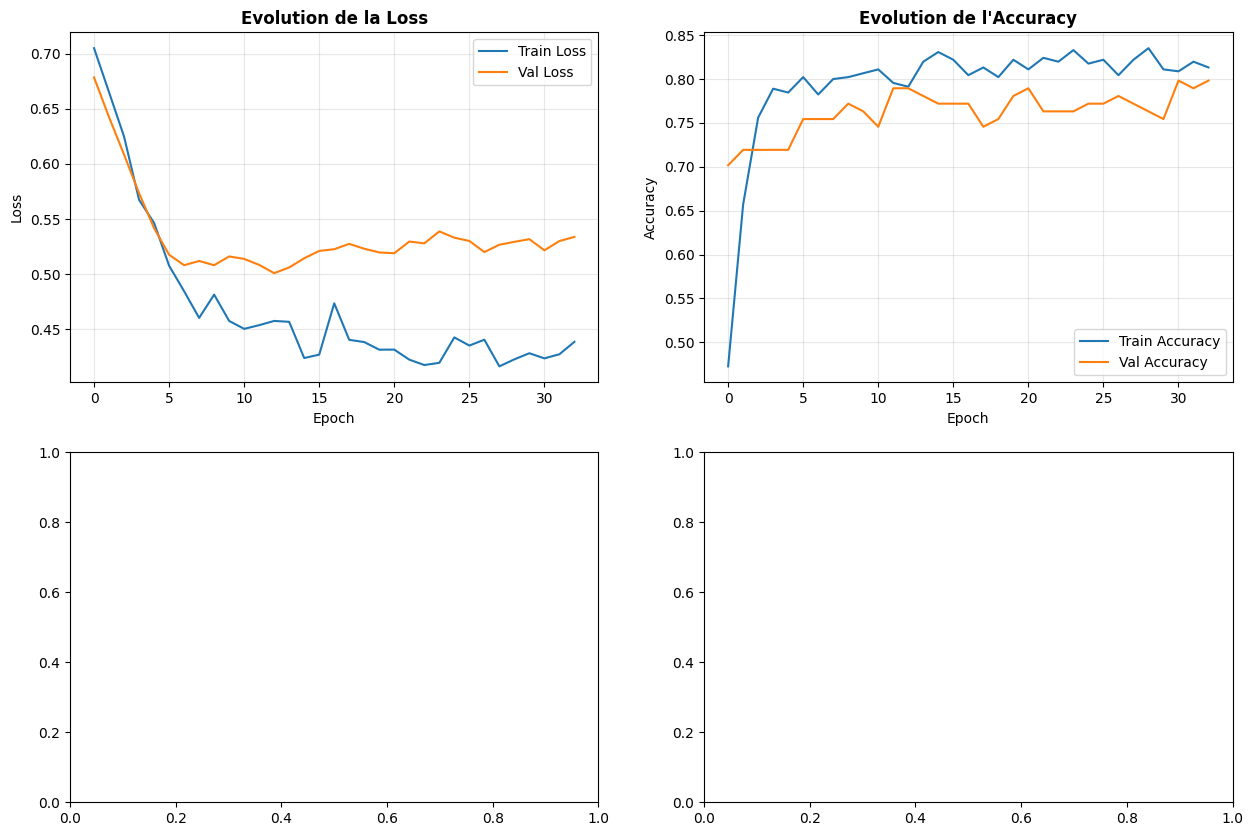

In [22]:
# Visualisation des courbes d'entraînement
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history.history['loss'], label='Train Loss')
axes[0, 0].plot(history.history['val_loss'], label='Val Loss')
axes[0, 0].set_title('Evolution de la Loss', fontsize=12, weight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Accuracy
axes[0, 1].plot(history.history['accuracy'], label='Train Accuracy')
axes[0, 1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0, 1].set_title('Evolution de l\'Accuracy', fontsize=12, weight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Precision
axes[1, 0].plot(history.history['precision'], label='Train Precision')
axes[1, 0].plot(history.history['val_precision'], label='Val Precision')
axes[1, 0].set_title('Evolution de la Precision', fontsize=12, weight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Recall
axes[1, 1].plot(history.history['recall'], label='Train Recall')
axes[1, 1].plot(history.history['val_recall'], label='Val Recall')
axes[1, 1].set_title('Evolution du Recall', fontsize=12, weight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Évaluation du modèle

In [ ]:
# Prédictions sur le test set
y_pred_proba = model.predict(X_test_scaled)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Métriques
print("=== Métriques sur le test set ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score  : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_pred_proba):.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
=== Métriques sur le test set ===
Accuracy  : 0.7762
Precision : 0.7407
Recall    : 0.6897
F1-score  : 0.7143
ROC-AUC   : 0.8523


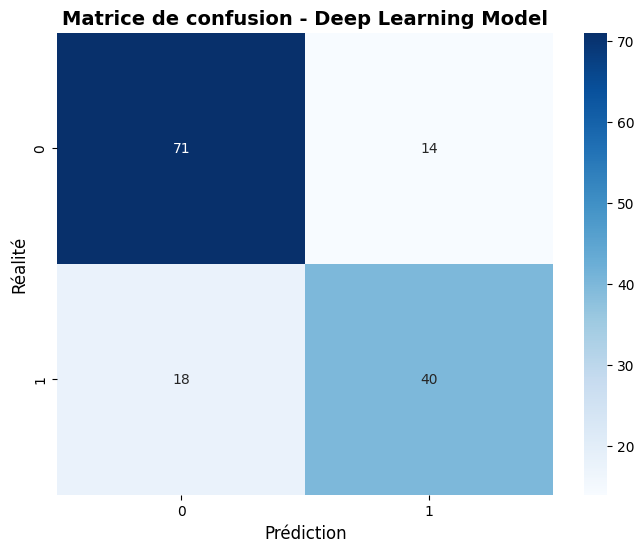

In [ ]:
# Matrice de confusion
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.xlabel('Prédiction', fontsize=12)
plt.ylabel('Réalité', fontsize=12)
plt.title('Matrice de confusion - Deep Learning Model', fontsize=14, weight='bold')
plt.show()

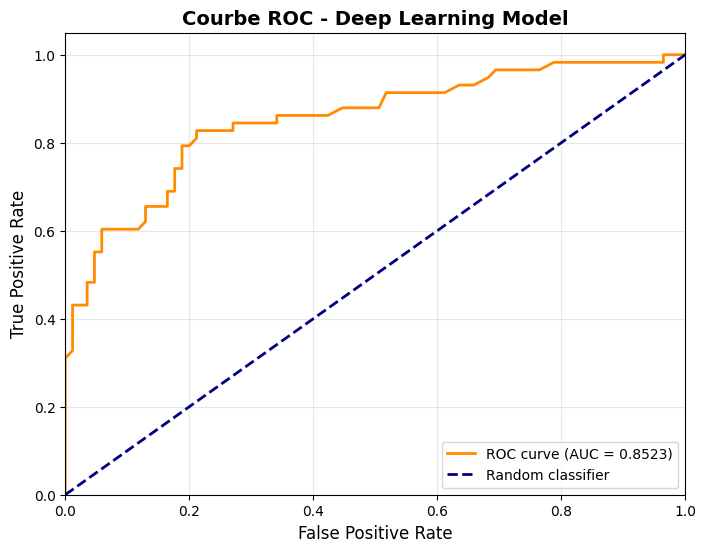

In [ ]:
# Courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Courbe ROC - Deep Learning Model', fontsize=14, weight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

## 6. Sauvegarde du modèle

In [ ]:
# Sauvegarder le modèle final
model.save('models/dl_model.keras')
print("Modèle sauvegardé : models/dl_model.keras")

# Sauvegarder le scaler
import joblib
joblib.dump(scaler, 'models/dl_scaler.pkl')
print("Scaler sauvegardé : models/dl_scaler.pkl")

# Sauvegarder les encoders
joblib.dump(le_sex, 'models/dl_le_sex.pkl')
joblib.dump(le_embarked, 'models/dl_le_embarked.pkl')
print("Encoders sauvegardés")

Modèle sauvegardé : models/dl_model.keras
Scaler sauvegardé : models/dl_scaler.pkl
Encoders sauvegardés


## 7. Comparaison ML vs DL


=== Comparaison ML vs DL ===
   Metric  ML Model  DL Model
 Accuracy  0.769231  0.776224
Precision  0.735849  0.740741
   Recall  0.672414  0.689655
 F1-Score  0.702703  0.714286


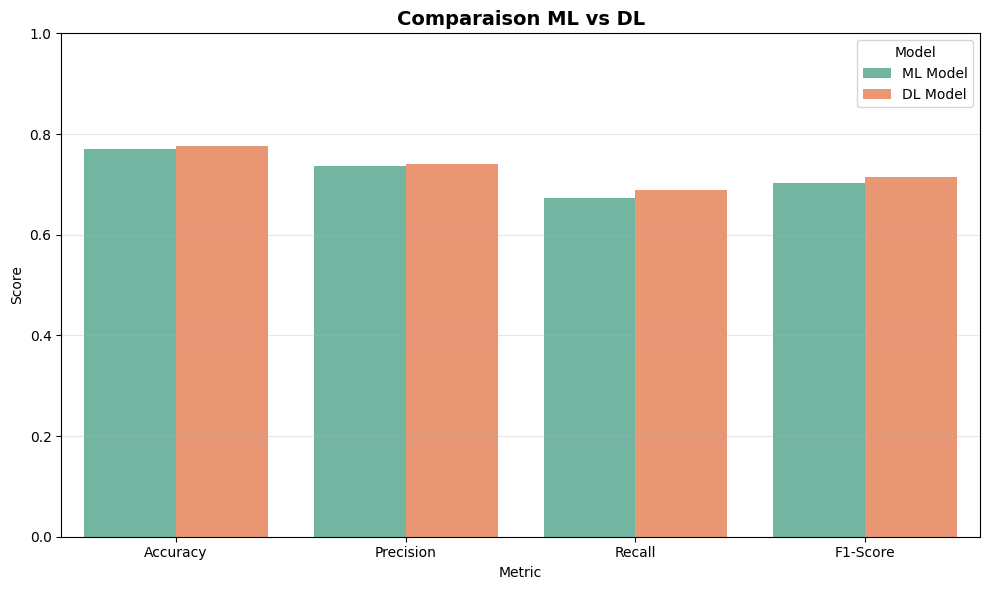

In [ ]:
# Charger le modèle ML pour comparaison
try:
    ml_model = joblib.load('models/ml_model.pkl')
    ml_scaler = joblib.load('models/ml_scaler.pkl')
    
    # Prédire avec le modèle ML (attention: utilise seulement Sex)
    X_test_ml = X_test[['Sex']].copy()
    X_test_ml_scaled = ml_scaler.transform(X_test_ml)
    y_pred_ml = ml_model.predict(X_test_ml_scaled)
    
    # Comparaison
    comparison = pd.DataFrame({
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
        'ML Model': [
            accuracy_score(y_test, y_pred_ml),
            precision_score(y_test, y_pred_ml),
            recall_score(y_test, y_pred_ml),
            f1_score(y_test, y_pred_ml)
        ],
        'DL Model': [
            accuracy_score(y_test, y_pred),
            precision_score(y_test, y_pred),
            recall_score(y_test, y_pred),
            f1_score(y_test, y_pred)
        ]
    })
    
    print("\n=== Comparaison ML vs DL ===")
    print(comparison.to_string(index=False))
    
    # Visualisation
    comparison_melted = comparison.melt(id_vars='Metric', var_name='Model', value_name='Score')
    plt.figure(figsize=(10, 6))
    sns.barplot(data=comparison_melted, x='Metric', y='Score', hue='Model', palette='Set2')
    plt.title('Comparaison ML vs DL', fontsize=14, weight='bold')
    plt.ylim(0, 1)
    plt.ylabel('Score')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
except FileNotFoundError:
    print("Modèle ML non trouvé. Entraînez d'abord le modèle ML dans ml_training.ipynb")
